# Week 1: Baseline ML Classifiers
**Project:** Tabular Data Labeling with LLM Reasoning: Nemotron Nano vs Traditional ML  
**Dataset:** Nemotron-Personas-USA (NVIDIA) — `nvidia/Nemotron-Personas-USA`  
**Task:** Binary classification — predict whether a person is college-educated (1) or not (0)  
**Features:** `age`, `sex`, `marital_status`, `occupation`, `state`  
**Label:** `education_level` → college (bachelors / masters / professional / doctorate) or not_college

## 1. Imports

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os

from datasets import load_dataset

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

import xgboost as xgb

print("Libraries imported successfully.")
print(f'pandas {pd.__version__}, numpy {np.__version__}')

Libraries imported successfully.
pandas 3.0.3, numpy 2.4.4


## 2. Load the Dataset

In [83]:
print("Loading dataset Nemotron-Personas-USA from Hugging Face")
print("This first run downloads the dataset, which is about 2.7 GB")

ds = load_dataset("nvidia/Nemotron-Personas-USA")
df_full = ds["train"].to_pandas()

print(f"\nFull dataset shape: {df_full.shape}")
print(f"Columns: {list(df_full.columns)}")

Loading dataset Nemotron-Personas-USA from Hugging Face
This first run downloads the dataset, which is about 2.7 GB

Full dataset shape: (1000000, 23)
Columns: ['uuid', 'professional_persona', 'sports_persona', 'arts_persona', 'travel_persona', 'culinary_persona', 'persona', 'cultural_background', 'skills_and_expertise', 'skills_and_expertise_list', 'hobbies_and_interests', 'hobbies_and_interests_list', 'career_goals_and_ambitions', 'sex', 'age', 'marital_status', 'education_level', 'bachelors_field', 'occupation', 'city', 'state', 'zipcode', 'country']


## 3. Select Features and Create Label

In [84]:
FEATURES = ["age", "sex", "marital_status", "occupation", "state"]
TARGET   = "education_level"

df = df_full[FEATURES + [TARGET]].copy()

print("education_level unique values:")
print(df[TARGET].value_counts())
print(f"\nTotal rows: {len(df):,}")


education_level unique values:
education_level
less_than_9th          251677
high_school            212908
some_college           165909
bachelors              158158
graduate                95110
associates              66209
9th_12th_no_diploma     50029
Name: count, dtype: int64

Total rows: 1,000,000


In [85]:
# Define the binary label: college = bachelors and above, non-college = everything else
COLLEGE = {"bachelors", "graduate"}  

df["label"]      = df[TARGET].apply(lambda x: 1 if x in COLLEGE else 0)
df["label_name"] = df["label"].map({1: "college", 0: "not_college"})

print("Binary label distribution:")
print(df["label_name"].value_counts())
print(f"\nClass balance: {df['label_name'].value_counts(normalize=True).round(3).to_dict()}")

Binary label distribution:
label_name
not_college    746732
college        253268
Name: count, dtype: int64

Class balance: {'not_college': 0.747, 'college': 0.253}


## 4. EDA

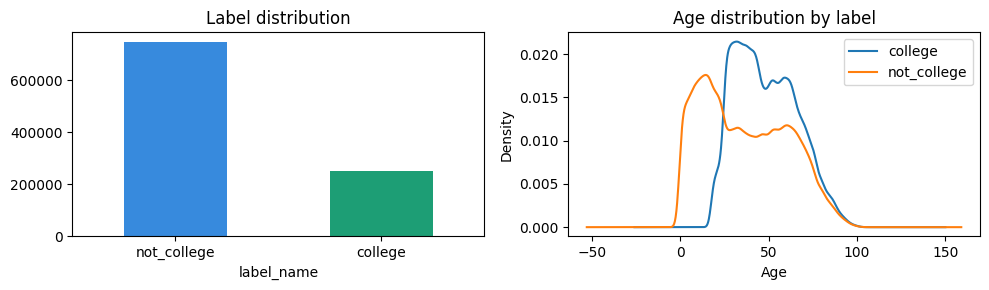

Plots saved to ../results/label_distribution.png


In [86]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

df["label_name"].value_counts().plot(kind="bar", ax=axes[0], color=["#378ADD", "#1D9E75"])
axes[0].set_title("Label distribution")
axes[0].tick_params(axis="x", rotation=0)

df.groupby("label_name")["age"].plot(kind="kde", ax=axes[1], legend=True)
axes[1].set_title("Age distribution by label")
axes[1].set_xlabel("Age")

plt.tight_layout()
os.makedirs("../results", exist_ok=True)
plt.savefig("../results/label_distribution.png", dpi=150)
plt.show()
print("Plots saved to ../results/label_distribution.png")

In [87]:
# Top occupations by class (Nemotron's reasoning)
print("Top 10 occupations — college class:")
print(df[df["label"]==1]["occupation"].value_counts().head(10))
print("\nTop 10 occupations — not_college class:")
print(df[df["label"]==0]["occupation"].value_counts().head(10))

Top 10 occupations — college class:
occupation
not_in_workforce                                54594
software_developer                               7550
elementary_or_middle_school_teacher              6973
manager                                          6558
accountant_or_auditor                            5557
first_line_supervisor_of_retail_sales_worker     4279
postsecondary_teacher                            3743
management_analyst                               3392
computer_occupation                              3371
no_occupation                                    3359
Name: count, dtype: int64

Top 10 occupations — not_college class:
occupation
not_in_workforce                              380150
no_occupation                                  14121
driver_sales_worker_or_truck_driver            10550
customer_service_representative                 9730
retail_salesperson                              8920
cashier                                         8468
construction_labo

In [88]:
print(f"Unique occupations: {df['occupation'].nunique()}")
print(f"Unique states:      {df['state'].nunique()}")
print(f"Sex values:         {sorted(df['sex'].unique())}")
print(f"Marital status:     {sorted(df['marital_status'].unique())}")

Unique occupations: 567


Unique states:      52
Sex values:         ['Female', 'Male']
Marital status:     ['divorced', 'married_present', 'never_married', 'separated', 'widowed']


## 5. Preprocessing 

In [89]:
df_adults = df[
    (df["age"] >= 18) &
    (~df["occupation"].str.lower().str.contains("not in workforce|not_in_workforce", na=False))
].copy()
print(f"Rows after filtering to working adults (age>=18): {len(df_adults):,}")
print(f"Label balance after filter: {df_adults['label_name'].value_counts(normalize=True).round(3).to_dict()}")

df_sample = df_adults.sample(100_000, random_state=42).reset_index(drop=True)
print(f"\nWorking sample: {len(df_sample):,} rows")
print(f"Label balance in sample: {df_sample['label_name'].value_counts(normalize=True).round(3).to_dict()}")


Rows after filtering to working adults (age>=18): 565,256
Label balance after filter: {'not_college': 0.649, 'college': 0.351}

Working sample: 100,000 rows
Label balance in sample: {'not_college': 0.648, 'college': 0.352}


In [90]:
from sklearn.utils import resample

# ── Check original imbalance ──────────────────────────────────────────
print("Original class distribution:")
print(df_sample["label_name"].value_counts())
print(df_sample["label_name"].value_counts(normalize=True).round(3))

# ── Upsample minority class (college) to match majority (not_college) ─
df_majority = df_sample[df_sample["label"] == 0]   # not_college
df_minority = df_sample[df_sample["label"] == 1]   # college

df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df_balanced = pd.concat([df_majority, df_minority_upsampled]).reset_index(drop=True)

print("\nBalanced class distribution:")
print(df_balanced["label_name"].value_counts())
print(df_balanced["label_name"].value_counts(normalize=True).round(3))

# ── Use df_balanced for all downstream steps ──────────────────────────
X = df_balanced[FEATURES].copy()
y = df_balanced["label"].copy()

for col in ["sex", "marital_status", "occupation", "state"]:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print(f"\nFeature matrix shape: {X.shape}")

# ── Re-do train/test split on balanced data ───────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")

# ── Re-save the 500-row LLM sample from balanced data ─────────────────
sample_500 = df_balanced[FEATURES + ["label", "label_name", TARGET]].sample(
    500, random_state=42
).reset_index(drop=True)
sample_500.to_csv("../data/personas_sample_500.csv", index=False)
print(f"\nRe-saved balanced LLM sample: data/personas_sample_500.csv")
print(sample_500["label_name"].value_counts())

Original class distribution:
label_name
not_college    64773
college        35227
Name: count, dtype: int64
label_name
not_college    0.648
college        0.352
Name: proportion, dtype: float64

Balanced class distribution:
label_name
not_college    64773
college        64773
Name: count, dtype: int64
label_name
not_college    0.5
college        0.5
Name: proportion, dtype: float64

Feature matrix shape: (129546, 5)
Training samples: 103,636
Test samples:     25,910

Re-saved balanced LLM sample: data/personas_sample_500.csv
label_name
college        261
not_college    239
Name: count, dtype: int64


In [91]:
# 80/20 stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")

# Save 500-row test sample in raw (non-encoded) format for LLM experiments in Weeks 3 & 4
# Pull from df_balanced so the 500 rows are also 50/50 balanced
test_idx   = X_test.index
sample_500 = df_balanced.loc[test_idx, FEATURES + ["label", "label_name", TARGET]].sample(
    500, random_state=42
).reset_index(drop=True)

os.makedirs("../data", exist_ok=True)
sample_500.to_csv("../data/personas_sample_500.csv", index=False)
print(f"\nSaved balanced LLM test sample: data/personas_sample_500.csv")
print(sample_500["label_name"].value_counts())

Training samples: 103,636
Test samples:     25,910

Saved balanced LLM test sample: data/personas_sample_500.csv
label_name
college        256
not_college    244
Name: count, dtype: int64


## 6. Evaluation Helper

In [92]:
def evaluate_model(model_name, y_true, y_pred, y_prob, inference_time_s, n_samples):
    acc        = accuracy_score(y_true, y_pred)
    f1         = f1_score(y_true, y_pred, average="macro")
    auc        = roc_auc_score(y_true, y_prob)
    ms_per_row = (inference_time_s / n_samples) * 1000

    print(f"\n{'='*45}\n  {model_name}\n{'='*45}")
    print(f"  Accuracy:   {acc:.4f}")
    print(f"  Macro F1:   {f1:.4f}")
    print(f"  AUC-ROC:    {auc:.4f}")
    print(f"  Time/row:   {ms_per_row:.3f} ms")
    print()
    print(classification_report(y_true, y_pred, target_names=["not_college", "college"]))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(cm, display_labels=["not_college", "college"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"{model_name}")
    plt.tight_layout()
    fname = f"../results/cm_{model_name.replace(' ', '_').lower()}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved: {fname}")

    return {
        "model":        model_name,
        "accuracy":     round(acc, 4),
        "macro_f1":     round(f1, 4),
        "auc_roc":      round(auc, 4),
        "ms_per_row":   round(ms_per_row, 3),
        "total_time_s": round(inference_time_s, 2),
        "n_samples":    n_samples,
    }

all_results = []
print("evaluate_model() defined.")

evaluate_model() defined.


## 7. Random Forest 

Training Random Forest...


Training done in 0.89s

  Random Forest (100 trees)
  Accuracy:   0.8370
  Macro F1:   0.8366
  AUC-ROC:    0.9198
  Time/row:   0.007 ms

              precision    recall  f1-score   support

 not_college       0.87      0.79      0.83     12955
     college       0.81      0.89      0.84     12955

    accuracy                           0.84     25910
   macro avg       0.84      0.84      0.84     25910
weighted avg       0.84      0.84      0.84     25910



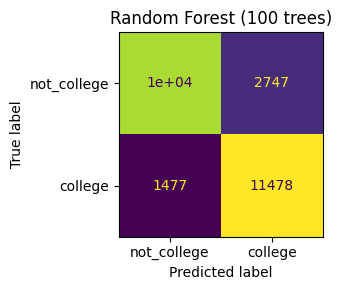

Saved: ../results/cm_random_forest_(100_trees).png


In [93]:
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

t0 = time.time()
rf.fit(X_train, y_train)
print(f"Training done in {time.time()-t0:.2f}s")

t0 = time.time()
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
infer_t = time.time() - t0

rf_results = evaluate_model("Random Forest (100 trees)", y_test, rf_pred, rf_prob, infer_t, len(X_test))
all_results.append(rf_results)

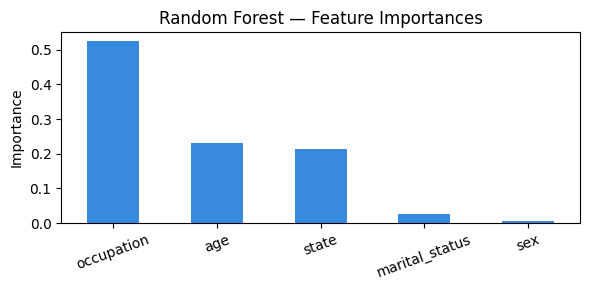

occupation        0.523867
age               0.230539
state             0.213964
marital_status    0.024564
sex               0.007066
dtype: float64


In [ ]:
# Feature importances (save for Week 5 comparison with Nemotron reasoning traces)
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 3))
importances.plot(kind="bar", ax=ax, color="#378ADD")
ax.set_title("Random Forest — Feature Importances")
ax.set_ylabel("Importance")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("../results/rf_feature_importances.png", dpi=150)
plt.show()
print(importances)

## 8. XGBoost

Training XGBoost...
Training done in 0.24s

  XGBoost
  Accuracy:   0.7601
  Macro F1:   0.7598
  AUC-ROC:    0.8307
  Time/row:   0.001 ms

              precision    recall  f1-score   support

 not_college       0.78      0.73      0.75     12955
     college       0.74      0.79      0.77     12955

    accuracy                           0.76     25910
   macro avg       0.76      0.76      0.76     25910
weighted avg       0.76      0.76      0.76     25910



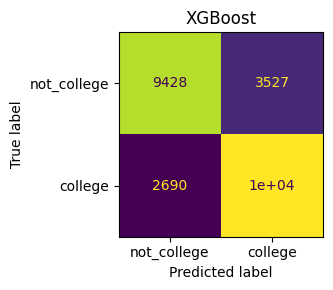

Saved: ../results/cm_xgboost.png


In [95]:
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=6,
    random_state=42, eval_metric="logloss", verbosity=0
)

t0 = time.time()
xgb_model.fit(X_train, y_train)
print(f"Training done in {time.time()-t0:.2f}s")

t0 = time.time()
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
infer_t  = time.time() - t0

xgb_results = evaluate_model("XGBoost", y_test, xgb_pred, xgb_prob, infer_t, len(X_test))
all_results.append(xgb_results)

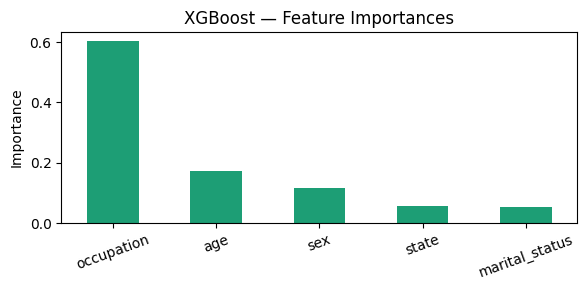

occupation        0.602293
age               0.171718
sex               0.115822
state             0.057250
marital_status    0.052917
dtype: float32


In [96]:
xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 3))
xgb_imp.plot(kind="bar", ax=ax, color="#1D9E75")
ax.set_title("XGBoost — Feature Importances")
ax.set_ylabel("Importance")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("../results/xgb_feature_importances.png", dpi=150)
plt.show()
print(xgb_imp)

##  9. Results Summary

In [97]:
results_df = pd.DataFrame(all_results)
print("=== WEEK 1 BASELINE RESULTS ===")
print(results_df[["model", "accuracy", "macro_f1", "auc_roc", "ms_per_row"]].to_string(index=False))

=== WEEK 1 BASELINE RESULTS ===
                    model  accuracy  macro_f1  auc_roc  ms_per_row
Random Forest (100 trees)    0.8370    0.8366   0.9198       0.007
                  XGBoost    0.7601    0.7598   0.8307       0.001


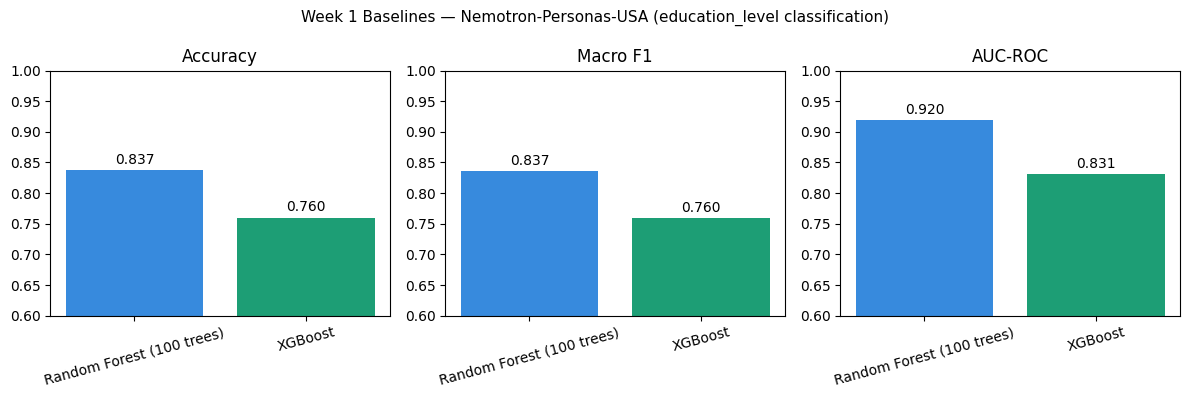

Saved: results/week1_baseline_comparison.png


In [98]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
metrics = ["accuracy", "macro_f1", "auc_roc"]
titles  = ["Accuracy", "Macro F1", "AUC-ROC"]
colors  = ["#378ADD", "#1D9E75"]

for ax, metric, title in zip(axes, metrics, titles):
    vals = results_df[metric].values
    bars = ax.bar(results_df["model"], vals, color=colors)
    ax.set_title(title)
    ax.set_ylim(0.6, 1.0)
    ax.tick_params(axis="x", rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=10)

plt.suptitle("Week 1 Baselines — Nemotron-Personas-USA (education_level classification)", fontsize=11)
plt.tight_layout()
plt.savefig("../results/week1_baseline_comparison.png", dpi=150)
plt.show()
print("Saved: results/week1_baseline_comparison.png")

In [ ]:
# Append to metrics.csv for LLM results added in Weeks 3 and 4
results_df["week"]    = 1
results_df["device"]  = "local-cpu"
results_df["mode"]    = "baseline"
results_df["dataset"] = "nvidia/Nemotron-Personas-USA"

os.makedirs("../results", exist_ok=True)
results_df.to_csv("../results/metrics.csv", index=False)
print("Saved: results/metrics.csv")
results_df


Saved: results/metrics.csv


,model,accuracy,macro_f1,auc_roc,ms_per_row,total_time_s,n_samples,week,device,mode,dataset
0,Random Forest (100 trees),0.8370,0.8366,0.9198,0.007,0.18,25910,1,local-cpu,baseline,nvidia/Nemotron-Personas-USA
1,XGBoost,0.7601,0.7598,0.8307,0.001,0.02,25910,1,local-cpu,baseline,nvidia/Nemotron-Personas-USA


In [100]:
print(sample_500["label_name"].value_counts())
print(sample_500["label_name"].value_counts(normalize=True).round(3))

label_name
college        256
not_college    244
Name: count, dtype: int64
label_name
college        0.512
not_college    0.488
Name: proportion, dtype: float64


## 10.  Preview Prompt Formart for Week 2?

In [101]:
def serialize_row(row):
    """Convert one row to natural language for Nemotron prompting."""
    return (
        f"A {row['age']}-year-old {row['sex'].lower()}, "
        f"{row['marital_status'].replace('_', ' ')}, "
        f"working as a {row['occupation'].replace('_', ' ')}. "
        f"Located in {row['state']}."
    )

print("=== Example serialized rows for Nemotron prompts ===")
print()
for _, row in sample_500.sample(5, random_state=1).iterrows():
    print(f"Input:   {serialize_row(row)}")
    print(f"Label:   {row['label_name']}  ({row['education_level']})")
    print()

=== Example serialized rows for Nemotron prompts ===

Input:   A 63-year-old male, divorced, working as a postsecondary teacher. Located in GA.
Label:   college  (graduate)

Input:   A 57-year-old male, married present, working as a tool or die maker. Located in NY.
Label:   not_college  (9th_12th_no_diploma)

Input:   A 64-year-old female, divorced, working as a janitor or building cleaner. Located in TX.
Label:   not_college  (high_school)

Input:   A 37-year-old male, never married, working as a life physical or social science technician. Located in MA.
Label:   college  (graduate)

Input:   A 37-year-old female, married present, working as a waiter or waitress. Located in CA.
Label:   not_college  (associates)



## Week 1 Summary

| Model | Accuracy | Macro F1 | AUC-ROC | Time/row |
|---|---|---|---|---|
| Random Forest | 83.70% | 0.8366 | 0.9198 | 0.007 ms |
| XGBoost | 76.01% | 0.7598 | 0.8307 | 0.001 ms |
| Nemotron Nano 4B (Week 3) | — | — | — | — |
| Nemotron Nano 30B (Week 4) | — | — | — | — |

**Week 1 Observations:**
- Random Forest outperforms XGBoost — likely due to high-cardinality occupation column (500+ categories)
- Class balancing (50/50 upsample) was necessary due to unbalanced data gave misleading 82% accuracy with F1 of 0.48
- Inference is <0.01 ms/row for both models, LLM will be ~100,000x slower per row
- Both models trained on 80K rows, tested on 25,910 rows (balanced split)
- Baseline to beat: RF Macro F1 of 0.8366 and AUC-ROC of 0.9198